# SCIONA Build Status Report Evaluation

This notebook loads all JSON files from `validations/build_status_reports/reports` and exposes the full report set through pandas DataFrames.

Available analysis surfaces:
- raw reports by repository
- repository totals
- per-language rows
- repository-by-scope rows
- repository-language-by-scope rows
- build phase timings in wide and long form

All nested report fields are flattened with dotted column names so the full payload remains accessible for filtering, grouping, plotting, and export.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


def resolve_reports_dir() -> Path:
    candidates = [
        Path("reports"),
        Path("validations/build_status_reports/reports"),
        Path.cwd() / "reports",
        Path.cwd() / "validations/build_status_reports/reports",
    ]
    for candidate in candidates:
        if candidate.exists() and candidate.is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not locate build status reports directory. "
        "Run this notebook from the repository root or from validations/build_status_reports/."
    )


REPORTS_DIR = resolve_reports_dir()
REPORT_FILES = sorted(REPORTS_DIR.glob("*.json"))
print(f"reports_dir={REPORTS_DIR}")
print(f"report_files={len(REPORT_FILES)}")
REPORT_FILES

reports_dir=reports
report_files=10


[PosixPath('reports/airbyte.json'),
 PosixPath('reports/axios.json'),
 PosixPath('reports/commons-lang.json'),
 PosixPath('reports/fastapi.json'),
 PosixPath('reports/guava.json'),
 PosixPath('reports/nest.json'),
 PosixPath('reports/pydantic.json'),
 PosixPath('reports/sympy.json'),
 PosixPath('reports/vscode.json'),
 PosixPath('reports/webpack.json')]

In [2]:
def flatten_dict(value: object, prefix: str = "") -> dict[str, object]:
    if not isinstance(value, dict):
        return {prefix: value} if prefix else {"value": value}
    flat: dict[str, object] = {}
    for key, nested in value.items():
        key = str(key)
        next_prefix = f"{prefix}.{key}" if prefix else key
        if isinstance(nested, dict):
            flat.update(flatten_dict(nested, next_prefix))
        else:
            flat[next_prefix] = nested
    return flat


def load_reports(files: list[Path]) -> dict[str, dict]:
    reports: dict[str, dict] = {}
    for path in files:
        reports[path.stem] = json.loads(path.read_text())
    return reports


def scope_rows_for_summary(repo: str, summary: dict) -> list[dict[str, object]]:
    totals = summary.get("totals", {})
    pair_scope = totals.get("callsite_pairs_by_scope", {}) or {}
    edge_scope = totals.get("finalized_call_edges_by_scope", {}) or {}
    funnel_scope = totals.get("call_site_funnel_by_scope", {}) or {}
    expansion_scope = totals.get("persisted_callsite_pair_expansion_by_scope", {}) or {}
    pre_persist_scope = totals.get("filtered_pre_persist_buckets_by_scope", {}) or {}
    rows: list[dict[str, object]] = []
    for scope in ("non_tests", "tests"):
        row = {"repo": repo, "scope": scope}
        row.update(flatten_dict(pair_scope.get(scope, {}), "callsite_pairs"))
        row.update(flatten_dict(edge_scope.get(scope, {}), "finalized_call_edges"))
        row.update(flatten_dict(funnel_scope.get(scope, {}), "call_site_funnel"))
        row.update(flatten_dict(expansion_scope.get(scope, {}), "persisted_callsite_pair_expansion"))
        row.update(flatten_dict(pre_persist_scope.get(scope, {}), "filtered_pre_persist_buckets"))
        rows.append(row)
    return rows


def language_scope_rows_for_summary(repo: str, summary: dict) -> list[dict[str, object]]:
    rows: list[dict[str, object]] = []
    for item in summary.get("languages", []):
        language = str(item.get("language") or "")
        pair_scope = item.get("callsite_pairs_by_scope", {}) or {}
        edge_scope = item.get("finalized_call_edges_by_scope", {}) or {}
        funnel_scope = item.get("call_site_funnel_by_scope", {}) or {}
        expansion_scope = item.get("persisted_callsite_pair_expansion_by_scope", {}) or {}
        pre_persist_scope = item.get("filtered_pre_persist_buckets_by_scope", {}) or {}
        for scope in ("non_tests", "tests"):
            row = {"repo": repo, "language": language, "scope": scope}
            row.update(flatten_dict(pair_scope.get(scope, {}), "callsite_pairs"))
            row.update(flatten_dict(edge_scope.get(scope, {}), "finalized_call_edges"))
            row.update(flatten_dict(funnel_scope.get(scope, {}), "call_site_funnel"))
            row.update(flatten_dict(expansion_scope.get(scope, {}), "persisted_callsite_pair_expansion"))
            row.update(flatten_dict(pre_persist_scope.get(scope, {}), "filtered_pre_persist_buckets"))
            rows.append(row)
    return rows


if not REPORT_FILES:
    raise RuntimeError(f"No report JSON files found under {REPORTS_DIR}")

reports = load_reports(REPORT_FILES)
sorted(reports)

['airbyte',
 'axios',
 'commons-lang',
 'fastapi',
 'guava',
 'nest',
 'pydantic',
 'sympy',
 'vscode',
 'webpack']

In [3]:
repo_rows: list[dict[str, object]] = []
language_rows: list[dict[str, object]] = []
repo_scope_rows: list[dict[str, object]] = []
language_scope_rows: list[dict[str, object]] = []
phase_rows: list[dict[str, object]] = []

for repo, report in reports.items():
    summary = report.get("summary", {})
    repo_row = {
        "repo": repo,
        "repo_root": report.get("repo_root"),
        "tool_version": report.get("tool_version"),
        "schema_version": report.get("schema_version"),
        "snapshot_count": report.get("snapshot_count"),
        "latest_snapshot": report.get("latest_snapshot"),
        "latest_created": report.get("latest_created"),
        "db_exists": report.get("db_exists"),
        "detailed": report.get("detailed"),
        "status_report_version": report.get("status_report_version"),
    }
    repo_row.update(flatten_dict(summary, "summary"))
    repo_rows.append(repo_row)

    for language_item in summary.get("languages", []):
        row = {"repo": repo, "language": language_item.get("language")}
        row.update(flatten_dict(language_item))
        language_rows.append(row)

    repo_scope_rows.extend(scope_rows_for_summary(repo, summary))
    language_scope_rows.extend(language_scope_rows_for_summary(repo, summary))

    for phase, seconds in (summary.get("build_phase_timings") or {}).items():
        phase_rows.append({"repo": repo, "phase": phase, "seconds": seconds})

repo_df = pd.DataFrame(repo_rows).sort_values("repo").reset_index(drop=True)
language_df = pd.DataFrame(language_rows).sort_values(["repo", "language"]).reset_index(drop=True)
repo_scope_df = pd.DataFrame(repo_scope_rows).sort_values(["repo", "scope"]).reset_index(drop=True)
language_scope_df = pd.DataFrame(language_scope_rows).sort_values(["repo", "language", "scope"]).reset_index(drop=True)
phase_long_df = pd.DataFrame(phase_rows).sort_values(["repo", "phase"]).reset_index(drop=True)
phase_wide_df = phase_long_df.pivot(index="repo", columns="phase", values="seconds").reset_index()

repo_df.shape, language_df.shape, repo_scope_df.shape, language_scope_df.shape, phase_long_df.shape

((10, 106), (22, 82), (20, 22), (44, 23), (100, 3))

## Primary DataFrames

- `repo_df`: one row per repository, with the full flattened `summary` payload
- `language_df`: one row per repository-language entry
- `repo_scope_df`: one row per repository-scope entry
- `language_scope_df`: one row per repository-language-scope entry
- `phase_long_df`: long-form build phase timings
- `phase_wide_df`: wide-form build phase timings

In [4]:
repo_df.head(3)

,repo,repo_root,tool_version,schema_version,snapshot_count,latest_snapshot,latest_created,db_exists,detailed,status_report_version,summary.snapshot_id,summary.created_at,summary.build_total_seconds,summary.build_wall_seconds,summary.build_phase_timings.build_structural_index,summary.build_phase_timings.compute_build_fingerprint,summary.build_phase_timings.derive_call_artifacts,summary.build_phase_timings.discover_files,summary.build_phase_timings.prepare_callsite_pairs,summary.build_phase_timings.prepare_snapshots,summary.build_phase_timings.rebuild_graph_index,summary.build_phase_timings.rebuild_graph_rollups,summary.build_phase_timings.register_modules,summary.build_phase_timings.write_callsite_pairs,summary.artifact_db_available,summary.callsite_pairs_semantics,summary.finalized_call_edges_semantics,summary.languages,summary.totals.files,summary.totals.nodes,summary.totals.edges,summary.totals.callsite_pairs.count,summary.totals.finalized_call_edges.count,summary.totals.call_site_funnel.observed_syntactic_callsites,summary.totals.call_site_funnel.filtered_pre_persist,summary.totals.call_site_funnel.persisted_callsites,summary.totals.call_site_funnel.persisted_accepted,summary.totals.call_site_funnel.persisted_dropped,summary.totals.call_site_funnel.record_drops.no_resolved_callees,summary.totals.call_site_funnel.conservation_ok,summary.totals.persisted_callsite_pair_expansion.persisted_callsites,summary.totals.persisted_callsite_pair_expansion.persisted_callsites_with_zero_pairs,summary.totals.persisted_callsite_pair_expansion.persisted_callsites_with_one_pair,summary.totals.persisted_callsite_pair_expansion.persisted_callsites_with_multiple_pairs,summary.totals.persisted_callsite_pair_expansion.pair_expansion_factor,summary.totals.persisted_callsite_pair_expansion.multi_pair_share,summary.totals.persisted_callsite_pair_expansion.max_pairs_for_single_persisted_callsite,summary.totals.callsite_pairs_by_scope.non_tests.count,summary.totals.callsite_pairs_by_scope.tests.count,summary.totals.finalized_call_edges_by_scope.non_tests.count,summary.totals.finalized_call_edges_by_scope.tests.count,summary.totals.call_site_funnel_by_scope.non_tests.observed_syntactic_callsites,summary.totals.call_site_funnel_by_scope.non_tests.filtered_pre_persist,summary.totals.call_site_funnel_by_scope.non_tests.persisted_callsites,summary.totals.call_site_funnel_by_scope.non_tests.persisted_accepted,summary.totals.call_site_funnel_by_scope.non_tests.persisted_dropped,summary.totals.call_site_funnel_by_scope.non_tests.record_drops.no_resolved_callees,summary.totals.call_site_funnel_by_scope.non_tests.conservation_ok,summary.totals.call_site_funnel_by_scope.tests.observed_syntactic_callsites,summary.totals.call_site_funnel_by_scope.tests.filtered_pre_persist,summary.totals.call_site_funnel_by_scope.tests.persisted_callsites,summary.totals.call_site_funnel_by_scope.tests.persisted_accepted,summary.totals.call_site_funnel_by_scope.tests.persisted_dropped,summary.totals.call_site_funnel_by_scope.tests.record_drops.no_resolved_callees,summary.totals.call_site_funnel_by_scope.tests.conservation_ok,summary.totals.persisted_callsite_pair_expansion_by_scope.non_tests.persisted_callsites,summary.totals.persisted_callsite_pair_expansion_by_scope.non_tests.persisted_callsites_with_zero_pairs,summary.totals.persisted_callsite_pair_expansion_by_scope.non_tests.persisted_callsites_with_one_pair,summary.totals.persisted_callsite_pair_expansion_by_scope.non_tests.persisted_callsites_with_multiple_pairs,summary.totals.persisted_callsite_pair_expansion_by_scope.non_tests.pair_expansion_factor,summary.totals.persisted_callsite_pair_expansion_by_scope.non_tests.multi_pair_share,summary.totals.persisted_callsite_pair_expansion_by_scope.non_tests.max_pairs_for_single_persisted_callsite,summary.totals.persisted_callsite_pair_expansion_by_scope.tests.persisted_callsites,summary.totals.persisted_callsite_pair_expansion_by_scope.tests.persisted_callsites_with_zero_pairs,summ

In [5]:
language_df.head(8)

,repo,language,files,nodes,edges,callsite_pairs.count,finalized_call_edges.count,call_site_funnel.observed_syntactic_callsites,call_site_funnel.filtered_pre_persist,call_site_funnel.persisted_callsites,call_site_funnel.persisted_accepted,call_site_funnel.persisted_dropped,call_site_funnel.record_drops.no_resolved_callees,call_site_funnel.conservation_ok,persisted_callsite_pair_expansion.persisted_callsites,persisted_callsite_pair_expansion.persisted_callsites_with_zero_pairs,persisted_callsite_pair_expansion.persisted_callsites_with_one_pair,persisted_callsite_pair_expansion.persisted_callsites_with_multiple_pairs,persisted_callsite_pair_expansion.pair_expansion_factor,persisted_callsite_pair_expansion.multi_pair_share,persisted_callsite_pair_expansion.max_pairs_for_single_persisted_callsite,filtered_pre_persist_buckets.no_in_repo_candidate_terminal,filtered_pre_persist_buckets.no_in_repo_candidate_qualified,filtered_pre_persist_buckets.accepted_outside_in_repo,filtered_pre_persist_buckets.invalid_observation_shape,callsite_pairs_by_scope.non_tests.count,callsite_pairs_by_scope.tests.count,finalized_call_edges_by_scope.non_tests.count,finalized_call_edges_by_scope.tests.count,call_site_funnel_by_scope.non_tests.observed_syntactic_callsites,call_site_funnel_by_scope.non_tests.filtered_pre_persist,call_site_funnel_by_scope.non_tests.persisted_callsites,call_site_funnel_by_scope.non_tests.persisted_accepted,call_site_funnel_by_scope.non_tests.persisted_dropped,call_site_funnel_by_scope.non_tests.record_drops.no_resolved_callees,call_site_funnel_by_scope.non_tests.conservation_ok,call_site_funnel_by_scope.tests.observed_syntactic_callsites,call_site_funnel_by_scope.tests.filtered_pre_persist,call_site_funnel_by_scope.tests.persisted_callsites,call_site_funnel_by_scope.tests.persisted_accepted,call_site_funnel_by_scope.tests.persisted_dropped,call_site_funnel_by_scope.tests.conservation_ok,persisted_callsite_pair_expansion_by_scope.non_tests.persisted_callsites,persisted_callsite_pair_expansion_by_scope.non_tests.persisted_callsites_with_zero_pairs,persisted_callsite_pair_expansion_by_scope.non_tests.persisted_callsites_with_one_pair,persisted_callsite_pair_expansion_by_scope.non_tests.persisted_callsites_with_multiple_pairs,persisted_callsite_pair_expansion_by_scope.non_tests.pair_expansion_factor,persisted_callsite_pair_expansion_by_scope.non_tests.multi_pair_share,persisted_callsite_pair_expansion_by_scope.non_tests.max_pairs_for_single_persisted_callsite,persisted_callsite_pair_expansion_by_scope.tests.persisted_callsites,persisted_callsite_pair_expansion_by_scope.tests.persisted_callsites_with_zero_pairs,persisted_callsite_pair_expansion_by_scope.tests.persisted_callsites_with_one_pair,persisted_callsite_pair_expansion_by_scope.tests.persisted_callsites_with_multiple_pairs,persisted_callsite_pair_expansion_by_scope.tests.pair_expansion_factor,persisted_callsite_pair_expansion_by_scope.tests.multi_pair_share,persisted_callsite_pair_expansion_by_scope.tests.max_pairs_for_single_persisted_callsite,structural_density.files,structural_density.discovered_files,structural_density.nodes,structural_density.eligible_callsites,structural_density.nodes_per_file,structural_density.eligible_callsites_per_file,structural_density.low_node_files_leq_1,structural_density.low_node_file_ratio,structural_density.inferred_zero_node_files,structural_density.inferred_zero_node_ratio,structural_density.top_low_node_dirs,structural_density.inflation_warning,structural_density.warnings,structural_density.zero_node_files_observed,structural_density.zero_node_files_note,filtered_pre_persist_buckets_by_scope.non_tests.no_in_repo_candidate_terminal,filtered_pre_persist_buckets_by_scope.non_tests.no_in_repo_candidate_qualified,filtered_pre_persist_buckets_by_scope.non_tests.accepted_outside_in_repo,filtered_pre_persist_buckets_by_scope.non_tests.invalid_observation_shape,filtered_pre_persist_buckets_by_scope.tests.no_in_repo_candidate_terminal,filtered_pre_p

In [6]:
repo_scope_df.head(6)

,repo,scope,callsite_pairs.count,finalized_call_edges.count,call_site_funnel.observed_syntactic_callsites,call_site_funnel.filtered_pre_persist,call_site_funnel.persisted_callsites,call_site_funnel.persisted_accepted,call_site_funnel.persisted_dropped,call_site_funnel.record_drops.no_resolved_callees,call_site_funnel.conservation_ok,persisted_callsite_pair_expansion.persisted_callsites,persisted_callsite_pair_expansion.persisted_callsites_with_zero_pairs,persisted_callsite_pair_expansion.persisted_callsites_with_one_pair,persisted_callsite_pair_expansion.persisted_callsites_with_multiple_pairs,persisted_callsite_pair_expansion.pair_expansion_factor,persisted_callsite_pair_expansion.multi_pair_share,persisted_callsite_pair_expansion.max_pairs_for_single_persisted_callsite,filtered_pre_persist_buckets.no_in_repo_candidate_terminal,filtered_pre_persist_buckets.no_in_repo_candidate_qualified,filtered_pre_persist_buckets.accepted_outside_in_repo,filtered_pre_persist_buckets.invalid_observation_shape
0,airbyte,non_tests,13848,13008,15012,891,14121,13836,285,287.0,True,14121,279,13836,6,0.980667,0.000425,2,0,0,0,0
1,airbyte,tests,605,605,614,5,609,605,4,4.0,True,609,4,605,0,0.993432,0.000000,1,0,0,0,0
2,axios,non_tests,158,156,224,66,158,154,4,20.0,True,158,2,154,2,1.000000,0.012658,2,0,0,0,0
3,axios,tests,7,7,7,0,7,7,0,NaN,True,7,0,7,0,1.000000,0.000000,1,0,0,0,0
4,commons-lang,non_tests,3667,3662,3403,7,3396,3325,71,1.0,True,3396,2,3325,69,1.079800,0.020318,10,0,0,0,0
5,commons-lang,tests,2051,2051,2289,198,2091,2051,40,79.0,True,2091,40,2051,0,0.980870,0.000000,1,0,0,0,0


In [7]:
language_scope_df.head(8)

,repo,language,scope,callsite_pairs.count,finalized_call_edges.count,call_site_funnel.observed_syntactic_callsites,call_site_funnel.filtered_pre_persist,call_site_funnel.persisted_callsites,call_site_funnel.persisted_accepted,call_site_funnel.persisted_dropped,call_site_funnel.record_drops.no_resolved_callees,call_site_funnel.conservation_ok,persisted_callsite_pair_expansion.persisted_callsites,persisted_callsite_pair_expansion.persisted_callsites_with_zero_pairs,persisted_callsite_pair_expansion.persisted_callsites_with_one_pair,persisted_callsite_pair_expansion.persisted_callsites_with_multiple_pairs,persisted_callsite_pair_expansion.pair_expansion_factor,persisted_callsite_pair_expansion.multi_pair_share,persisted_callsite_pair_expansion.max_pairs_for_single_persisted_callsite,filtered_pre_persist_buckets.no_in_repo_candidate_terminal,filtered_pre_persist_buckets.no_in_repo_candidate_qualified,filtered_pre_persist_buckets.accepted_outside_in_repo,filtered_pre_persist_buckets.invalid_observation_shape
0,airbyte,java,non_tests,1108,1108,1159.0,50.0,1109.0,1096.0,13.0,28.0,True,1109.0,7.0,1096.0,6.0,0.999098,0.00541,2.0,0,0,0,0
1,airbyte,java,tests,460,460,464.0,4.0,460.0,460.0,0.0,NaN,True,460.0,0.0,460.0,0.0,1.000000,0.00000,1.0,0,0,0,0
2,airbyte,javascript,non_tests,53,53,53.0,0.0,53.0,53.0,0.0,NaN,True,53.0,0.0,53.0,0.0,1.000000,0.00000,1.0,0,0,0,0
3,airbyte,javascript,tests,0,0,0.0,0.0,0.0,0.0,0.0,NaN,True,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0,0,0,0
4,airbyte,python,non_tests,12685,11845,13798.0,841.0,12957.0,12685.0,272.0,259.0,True,12957.0,272.0,12685.0,0.0,0.979007,0.00000,1.0,0,0,0,0
5,airbyte,python,tests,145,145,150.0,1.0,149.0,145.0,4.0,4.0,True,149.0,4.0,145.0,0.0,0.973154,0.00000,1.0,0,0,0,0
6,airbyte,typescript,non_tests,2,2,2.0,0.0,2.0,2.0,0.0,NaN,True,2.0,0.0,2.0,0.0,1.000000,0.00000,1.0,0,0,0,0
7,airbyte,typescript,tests,0,0,0.0,0.0,0.0,0.0,0.0,NaN,True,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0,0,0,0


## Convenience Views

In [8]:
repo_totals_view = repo_df[[
    "repo",
    "summary.totals.files",
    "summary.totals.nodes",
    "summary.totals.edges",
    "summary.totals.call_site_funnel.observed_syntactic_callsites",
    "summary.totals.call_site_funnel.filtered_pre_persist",
    "summary.totals.call_site_funnel.persisted_callsites",
    "summary.totals.callsite_pairs.count",
    "summary.totals.finalized_call_edges.count",
    "summary.totals.persisted_callsite_pair_expansion.pair_expansion_factor",
    "summary.totals.persisted_callsite_pair_expansion.multi_pair_share",
    "summary.build_total_seconds",
]]
repo_totals_view

,repo,summary.totals.files,summary.totals.nodes,summary.totals.edges,summary.totals.call_site_funnel.observed_syntactic_callsites,summary.totals.call_site_funnel.filtered_pre_persist,summary.totals.call_site_funnel.persisted_callsites,summary.totals.callsite_pairs.count,summary.totals.finalized_call_edges.count,summary.totals.persisted_callsite_pair_expansion.pair_expansion_factor,summary.totals.persisted_callsite_pair_expansion.multi_pair_share,summary.build_total_seconds
0,airbyte,3288,25275,24450,15626,896,14730,14453,13613,0.981195,0.000407,67.590402
1,axios,173,576,642,231,66,165,165,163,1.000000,0.012121,2.788000
2,commons-lang,534,11566,11603,5692,205,5487,5718,5713,1.042100,0.012575,19.170011
3,fastapi,1287,6604,7038,2310,1078,1232,716,716,0.581169,0.000000,11.045890
4,guava,3245,64131,67212,36639,1266,35373,36099,36064,1.020524,0.009979,166.982051
5,nest,1708,6416,8005,2353,342,2011,2203,2195,1.095475,0.022377,15.889046
6,pydantic,407,13301,14019,3263,848,2415,2273,2264,0.941201,0.000000,20.869114
7,sympy,1590,40980,52633,72663,25344,47319,47109,46558,0.995562,0.000000,165.439326
8,vscode,6765,108097,171474,155451,10208,145243,176856,175171,1.217656,0.019071,667.966175
9,webpack,8703,14945,11253,3368,156,3212,3189,3175,0.992839,0.005604,43.668829


In [9]:
language_totals_view = language_df[[
    "repo",
    "language",
    "files",
    "nodes",
    "edges",
    "call_site_funnel.observed_syntactic_callsites",
    "call_site_funnel.filtered_pre_persist",
    "call_site_funnel.persisted_callsites",
    "callsite_pairs.count",
    "finalized_call_edges.count",
    "persisted_callsite_pair_expansion.pair_expansion_factor",
    "persisted_callsite_pair_expansion.multi_pair_share",
]]
language_totals_view.head(20)

,repo,language,files,nodes,edges,call_site_funnel.observed_syntactic_callsites,call_site_funnel.filtered_pre_persist,call_site_funnel.persisted_callsites,callsite_pairs.count,finalized_call_edges.count,persisted_callsite_pair_expansion.pair_expansion_factor,persisted_callsite_pair_expansion.multi_pair_share
0,airbyte,java,473,4144,3829,1623,54,1569,1568,1568,0.999363,0.003824
1,airbyte,javascript,44,147,127,53,0,53,53,53,1.000000,0.000000
2,airbyte,python,2768,20976,20488,13948,842,13106,12830,11990,0.978941,0.000000
3,airbyte,typescript,3,8,6,2,0,2,2,2,1.000000,0.000000
4,axios,javascript,167,438,510,231,66,165,165,163,1.000000,0.012121
5,axios,typescript,6,138,132,0,0,0,0,0,NaN,NaN
6,commons-lang,java,534,11566,11603,5692,205,5487,5718,5713,1.042100,0.012575
7,fastapi,javascript,3,25,22,22,0,22,22,22,1.000000,0.000000
8,fastapi,python,1284,6579,7016,2288,1078,1210,694,694,0.573554,0.000000
9,guava,java,3243,64129,67212,36639,1266,35373,36099,36064,1.020524,0.009979


## Grouped Aggregations

In [10]:
language_grouped = (
    language_df.groupby("language", as_index=False)
    .agg({
        "files": "sum",
        "nodes": "sum",
        "edges": "sum",
        "call_site_funnel.observed_syntactic_callsites": "sum",
        "call_site_funnel.filtered_pre_persist": "sum",
        "call_site_funnel.persisted_callsites": "sum",
        "callsite_pairs.count": "sum",
        "finalized_call_edges.count": "sum",
        "filtered_pre_persist_buckets.no_in_repo_candidate_terminal": "sum",
        "filtered_pre_persist_buckets.no_in_repo_candidate_qualified": "sum",
        "filtered_pre_persist_buckets.accepted_outside_in_repo": "sum",
        "filtered_pre_persist_buckets.invalid_observation_shape": "sum",
    })
)
language_grouped

,language,files,nodes,edges,call_site_funnel.observed_syntactic_callsites,call_site_funnel.filtered_pre_persist,call_site_funnel.persisted_callsites,callsite_pairs.count,finalized_call_edges.count,filtered_pre_persist_buckets.no_in_repo_candidate_terminal,filtered_pre_persist_buckets.no_in_repo_candidate_qualified,filtered_pre_persist_buckets.accepted_outside_in_repo,filtered_pre_persist_buckets.invalid_observation_shape
0,java,4251,79844,82648,43954,1525,42429,43385,43345,0,1525,0,0
1,javascript,8991,15838,12126,3797,223,3574,3550,3534,0,223,0,0
2,python,6046,81834,94157,92154,28112,64042,62898,61498,0,28112,0,0
3,typescript,8412,114375,179398,157691,10549,147142,178948,177255,0,10549,0,0


In [11]:
scope_grouped = (
    repo_scope_df.groupby("scope", as_index=False)
    .agg({
        "callsite_pairs.count": "sum",
        "finalized_call_edges.count": "sum",
        "call_site_funnel.observed_syntactic_callsites": "sum",
        "call_site_funnel.filtered_pre_persist": "sum",
        "call_site_funnel.persisted_callsites": "sum",
        "filtered_pre_persist_buckets.no_in_repo_candidate_terminal": "sum",
        "filtered_pre_persist_buckets.no_in_repo_candidate_qualified": "sum",
        "filtered_pre_persist_buckets.accepted_outside_in_repo": "sum",
        "filtered_pre_persist_buckets.invalid_observation_shape": "sum",
    })
)
scope_grouped

,scope,callsite_pairs.count,finalized_call_edges.count,call_site_funnel.observed_syntactic_callsites,call_site_funnel.filtered_pre_persist,call_site_funnel.persisted_callsites,filtered_pre_persist_buckets.no_in_repo_candidate_terminal,filtered_pre_persist_buckets.no_in_repo_candidate_qualified,filtered_pre_persist_buckets.accepted_outside_in_repo,filtered_pre_persist_buckets.invalid_observation_shape
0,non_tests,223707,221074,210806,17785,193021,0,0,0,0
1,tests,65074,64558,86790,22624,64166,0,0,0,0


## Example Plots

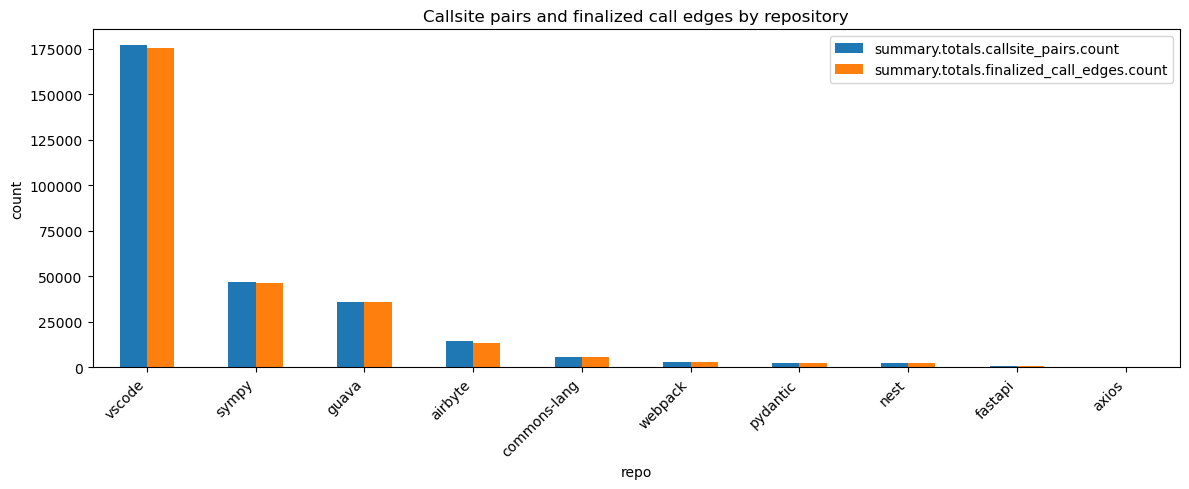

In [12]:
plot_df = repo_totals_view.sort_values("summary.totals.callsite_pairs.count", ascending=False)
ax = plot_df.plot(
    kind="bar",
    x="repo",
    y=["summary.totals.callsite_pairs.count", "summary.totals.finalized_call_edges.count"],
    figsize=(12, 5),
    title="Callsite pairs and finalized call edges by repository",
)
ax.set_ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

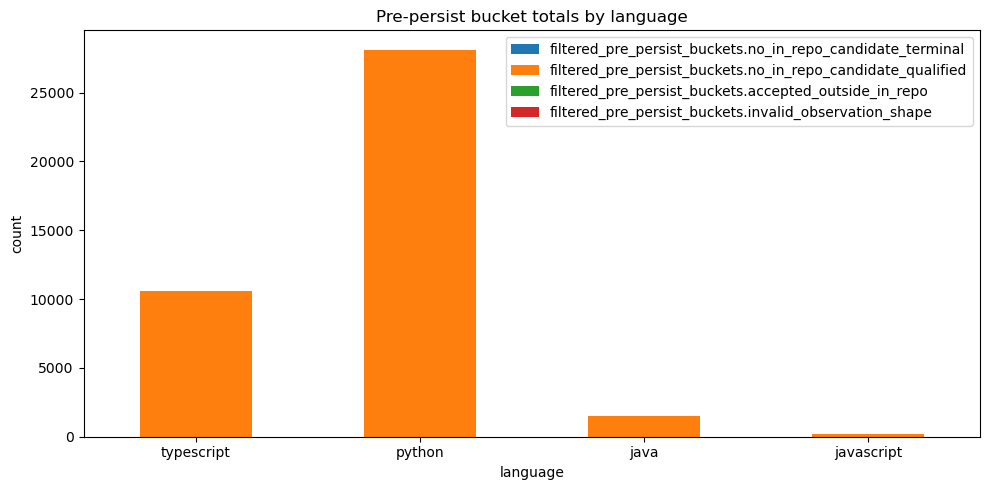

In [13]:
plot_lang = language_grouped.sort_values("callsite_pairs.count", ascending=False)
ax = plot_lang.plot(
    kind="bar",
    x="language",
    y=[
        "filtered_pre_persist_buckets.no_in_repo_candidate_terminal",
        "filtered_pre_persist_buckets.no_in_repo_candidate_qualified",
        "filtered_pre_persist_buckets.accepted_outside_in_repo",
        "filtered_pre_persist_buckets.invalid_observation_shape",
    ],
    stacked=True,
    figsize=(10, 5),
    title="Pre-persist bucket totals by language",
)
ax.set_ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()

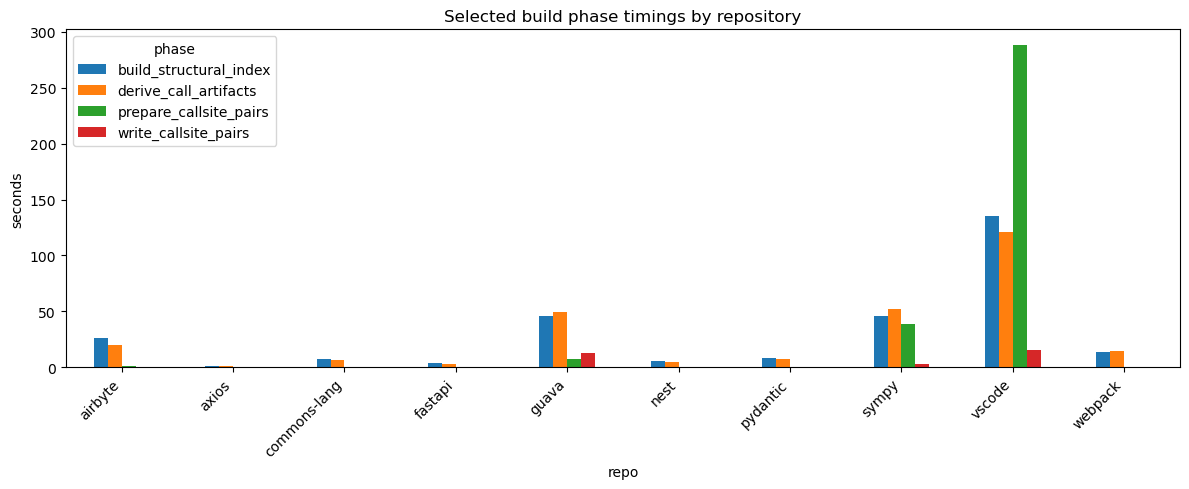

In [14]:
phase_plot = phase_wide_df.set_index("repo")[['build_structural_index', 'derive_call_artifacts', 'prepare_callsite_pairs', 'write_callsite_pairs']]
ax = phase_plot.plot(kind="bar", stacked=False, figsize=(12, 5), title="Selected build phase timings by repository")
ax.set_ylabel("seconds")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

## Raw Access Helpers

Use these helpers when you want direct access to a raw report or filtered subsets of the DataFrames.

In [15]:
def report_for(repo: str) -> dict:
    return reports[repo]


def rows_for_repo(repo: str) -> pd.DataFrame:
    return language_df[language_df['repo'] == repo].copy()


def rows_for_language(language: str) -> pd.DataFrame:
    return language_df[language_df['language'] == language].copy()


def scope_rows(scope: str) -> pd.DataFrame:
    return repo_scope_df[repo_scope_df['scope'] == scope].copy()


report_for('vscode')['summary']['totals']['persisted_callsite_pair_expansion']

{'persisted_callsites': 145243,
 'persisted_callsites_with_zero_pairs': 987,
 'persisted_callsites_with_one_pair': 141486,
 'persisted_callsites_with_multiple_pairs': 2770,
 'pair_expansion_factor': 1.2176559283407806,
 'multi_pair_share': 0.019071487094042397,
 'max_pairs_for_single_persisted_callsite': 1253}